Parte 1 - Declaramos nuestras librerias/bibliotecas IMPORTAR LIBRERIAS

In [1]:
import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns

from google.colab import files

Parte 2 - seccion para cargar la Base de datos de mi computadora
link de acceso original: https://data.buenosaires.gob.ar/sl/dataset/encuesta-centros-atencion-turistica-cat/resource/juqdkmgo-942-resource

Resultado de base de datos encuestas en Centros de Atención Turística (CAT) en 2017-2018 tomada de la pagina oficial del GCBA. Fecha de ultima actualizacion 18 de Junio de 2026 fecha de descarga 18/09/2026

In [2]:
from google.colab import files
files.upload()
df= pd.read_csv("resultado-de-encuestas-2017-2018.csv")
print("La base se cargó correctamente")

#df= pd.read_excel

Saving resultado-de-encuestas-2017-2018.csv to resultado-de-encuestas-2017-2018.csv
La base se cargó correctamente


/tmp/ipykernel_1600/4176579537.py:3: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("resultado-de-encuestas-2017-2018.csv")


# Parte 3 - Primer Analisis descriptivo para conocer como esta formada

In [3]:
print("Cantidad de filas y columnas")
print(df.shape)

print("Nombre de mis columnas/variables:")
print(df.columns)

# genera conocer tipo de datos ( enteros )
print("Información general de las variables con las que voy a trabajar:")
print(df.info)

Cantidad de filas y columnas
(174812, 20)
Nombre de mis columnas/variables:
Index(['id', 'fecha', 'centro_atencion_turistica', 'barrio', 'comuna',
       'pasajeros', 'pais_residencia_si_extranjero',
       'otro_pais_residencia_si_extranjero',
       'provincia_residencia_si_argentino', 'pernoctaciones',
       'medio_transporte_llegada', 'alojamiento', 'otro_alojamiento',
       'barrio.1', 'otro_barrio', 'primera_vez', 'motivo_viaje',
       'otro_motivo_viaje', 'motivo_consulta', 'otro_motivo_consulta'],
      dtype='object')
Información general de las variables con las que voy a trabajar:
<bound method DataFrame.info of             id       fecha centro_atencion_turistica       barrio    comuna  \
0            1  2017-01-02                    retiro       RETIRO  COMUNA 1   
1            2  2017-01-02                    retiro       RETIRO  COMUNA 1   
2            3  2017-01-02                    retiro       RETIRO  COMUNA 1   
3            4  2017-01-02                    retir

Parte 4 - Quiero conocer como estan almacenados mis datos

Analisis descriptivo de una variable determinada

In [4]:
#Analizo Funcion Principal
df["centro_atencion_turistica"].value_counts()

,count
centro_atencion_turistica,
florida,40133
recoleta,32344
hub2,23753
caminito,16947
pzasanmartin,16363
planetario,15086
puertomadero,11770
retiro,10113
aeroparque,4676


In [5]:
#Analizo BARRIO
df["barrio"].value_counts()

,count
barrio,
SAN NICOLAS,65936
RECOLETA,32640
RETIRO,26669
PALERMO,20304
BOCA,17078
PUERTO MADERO,12160
BARRIO,18
SIN IDENTIFICAR,7


Vamos a cruzar barrio y punto cat/// Florida = San Nicolas

parte 5 - encontrar duplicados

In [6]:
print("¿Hay duplicados?")
print(df.duplicated().sum())

¿Hay duplicados?
0


# ahora vamos a modificar y estandarizar nuestros datos

In [40]:
import pandas as pd
# Reload df from the original CSV to ensure it has the correct columns
df = pd.read_csv("resultado-de-encuestas-2017-2018.csv")

df2=df[['id','fecha', 'centro_atencion_turistica', 'barrio', 'pasajeros', 'pais_residencia_si_extranjero',
        'otro_pais_residencia_si_extranjero', 'provincia_residencia_si_argentino','primera_vez', 'motivo_consulta']]

        #df2 (nombre del archivo que estamos modificando)

print("tu nuevo dataframe esta creado")

tu nuevo dataframe esta creado


/tmp/ipykernel_1600/1188355074.py:3: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("resultado-de-encuestas-2017-2018.csv")


In [8]:
#df2=df[['fecha', 'centro_atencion_turistica', 'barrio', 'pasajeros', 'pais_residencia_si_extranjero',
#        'otro_pais_residencia_si_extranjero', 'provincia_residencia_si_argentino','primera_vez']]

# Renombramos las columnas para facilitar analisis ⏰:⏰

In [41]:
df2=df2.rename(columns={'id':'id',
                        'fecha':'fecha',
                        'centro_atencion_turistica':'cat',
                        'barrio':'barrio',
                        'pasajeros':'pasajeros',
                        'pais_residencia_si_extranjero': 'pais_extranjero',
                        'otro_pais_residencia_si_extranjero': 'otro_pais_extranjero',
                        'provincia_residencia_si_argentino': 'provincia_argentina',
                        'primera_vez':'primera_visita'

                        })

print("Columans renombradas ok")

Columans renombradas ok


# parte 6
La lógica será la siguiente: si en la columna pais_extranjero hay un país, entonces, mantengo ese valor.

Si la columna pais_extranjero no tiene datos pero sí encontramos un dato en otro_pais_extranjero, entonces, me quedo con ese valor.

Si no, si no hay datos ni en país extranjero ni en otro_pais_extranjero, reviso si hay datos en provincia_argentina. Si los hay, completo en mi nueva columna el valor 'Argentina'.

In [42]:
df2['pais'] = ( df2['pais_extranjero']
               .replace('Otro paí­s de residencia si es extranjero',pd.NA)
               .fillna(df2['otro_pais_extranjero'])

               )

df2.loc[df2['pais'].isna() & df2['provincia_argentina'].notna(),
       "pais" ] = 'Argentina'


# Parte 7 - Vamos a unificar la manera de escribir los datos de nuestra Base
pasaremos los barrios, las comunas, los paises, los puntos cat a "Nombre Propio" (Title)

In [11]:
df2['comuna'] = df['comuna']
df2['barrio'] = df2['barrio'].str.title()
df2['comuna'] = df2['comuna'].str.title()
df2['pais'] = df2['pais'].str.title()
df2['cat'] = df2['cat'].str.title()



print("cambios realizados")
df2.head()

cambios realizados


,id,fecha,cat,barrio,pasajeros,pais_extranjero,otro_pais_extranjero,provincia_argentina,primera_visita,pais,comuna
0,1,2017-01-02,Retiro,Retiro,2,Chile,NaN,NaN,No especifica,Chile,Comuna 1
1,2,2017-01-02,Retiro,Retiro,1,NaN,NaN,Provincia de Buenos Aires,No especifica,Argentina,Comuna 1
2,3,2017-01-02,Retiro,Retiro,2,NaN,NaN,Córdoba,No especifica,Argentina,Comuna 1
3,4,2017-01-02,Retiro,Retiro,2,Francia,NaN,NaN,No especifica,Francia,Comuna 1
4,5,2017-01-02,Retiro,Retiro,1,México,NaN,NaN,No especifica,México,Comuna 1


# Parte 8/ parte 1 - Vamos a verificar los puntos CAT y modificarlos, en caso de que sea necesario.

In [12]:
#Vamos a tener que unificar esos valores en menos categorias:
#Florida, Retiro, Puerto Madero, Hub, Aeroparque, Caminito, Planetario, Plaza San Martín, Casco Histórico

equivalencias = {
    "Florida2":"Florida",
    "Florida (Unauthenticated)": "Florida",
    "Florida (Authenticated As Null)": "Florida",

    "Recoleta2":"Recoleta",
    "Recoleta (Unauthenticated)": "Recoleta",
    "Recoleta (Authenticated As Null)": "Recoleta",

    "Puertomadero2": "Puerto Madero",
    "Puertomadero":"Puerto Madero",
    "Puertomadero (Unauthenticated)":"Puerto Madero",
    "Puertomadero (Authenticated As Null)":"Puerto Madero",

    "Hub2": "Hub",
    "Hub2 (Unauthenticated)": "Hub",
    "Hub2 (Authenticated As Null)": "Hub",


     "Caminito2": "Caminito",
    "Caminito (Unauthenticated)": "Caminito",
    "Caminito (Authenticated As Null)": "Caminito",

     "Pzasanmartin": "Plaza San Martín",
    "Pzasanmartin (Unauthenticated)": "Plaza San Martín",
    "Pzasanmartin (Authenticated As Null)": "Plaza San Martín",


     "Planetario2": "Planetario",
    "Planetario (Unauthenticated)": "Planetario",
    "Planetario (Authenticated As Null)": "Planetario",


      "Retiro2": "Retiro",
    "Retiro (Unauthenticated)": "Retiro",
    "Retiro (Authenticated As Null)": "Retiro",
    "Retiro (Authenticated As Aeroparque)": "Retiro",

    "Aeroparque2": "Aeroparque",
    "Aeroparque (Unauthenticated)": "Aeroparque",
    "Aeroparque (Authenticated As Null)": "Aeroparque",

    "Casco Hist├│Rico": "Casco Histórico",
    "Casco Hist├│Rico (Authenticated As Retiro)": "Casco Histórico"

}

df2["cat"] = df2["cat"].replace(equivalencias)

df2["cat"].value_counts()

,count
cat,
Florida,41821
Recoleta,32661
Hub,23775
Caminito,17079
Plaza San Martín,16370
Planetario,15226
Puerto Madero,12169
Retiro,10301
Aeroparque,5062


# Parte 8/ parte 2 - Modificamos los nombres de los paises y buscamos equivalencia

In [13]:
df2["cat"].unique()
#df2["cat"].value_counts()

array(['Retiro', 'Florida', 'Recoleta', 'Puerto Madero', 'Hub',
       'Caminito', 'Aeroparque', 'Planetario', 'Plaza San Martín', nan,
       'Casco Histórico', ' (Unauthenticated)'], dtype=object)

In [14]:
equivalencias_paises = {
    # Argentina
    "Arg": "Argentina",
    "Argentina ": "Argentina",
    "Buenos Aires": "Argentina",
    "Buenos Aires, Argentina": "Argentina",
    "Mendoza": "Argentina",
    "Cordoba": "Argentina",
    "Córdoba": "Argentina",
    "Caba": "Argentina",

    # Chile
    "Chile": "Chile",

    # Brasil
    "Brasil": "Brasil",

    # Bolivia
    "Bolivia": "Bolivia",

    # Perú
    "Peru": "Perú",
    "Perú": "Perú",

    # México
    "México": "México",

    # Colombia
    "Colombia": "Colombia",

    # Uruguay
    "Uruguay": "Uruguay",

    # Ecuador
    "Ecuador": "Ecuador",
    "Galapagos ": "Ecuador",

    # Paraguay
    "Paraguay": "Paraguay",

    # Venezuela
    "Venezuela": "Venezuela",
    "Venezuela-Residentes": "Venezuela",

    # Centroamérica y Caribe
    "Costa Rica": "Costa Rica",
    "Costa Rica ": "Costa Rica",
    "Guatemala": "Guatemala",
    "Guatemala ": "Guatemala",
    "Guatemela": "Guatemala",
    "Guatemalteco": "Guatemala",
    "Honduras": "Honduras",
    "Honduras ": "Honduras",
    "Hondura": "Honduras",
    "El Salvador": "El Salvador",
    "El Salvador ": "El Salvador",
    "Salvador ": "El Salvador",
    "Nicaragua": "Nicaragua",
    "Panama": "Panamá",
    "Panamá": "Panamá",
    "Cuba": "Cuba",
    "Puerto Rico": "Puerto Rico",
    "Pto Rico": "Puerto Rico",
    "Dominicana": "República Dominicana",
    "R Dominicana": "República Dominicana",
    "Rep Dominicana": "República Dominicana",
    "Rep. Dominicana": "República Dominicana",
    "República Dominicana": "República Dominicana",
    "Republica Dominicana": "República Dominicana",
    "Reo.Dominicana": "República Dominicana",
    "Trinidad Y Tobago ": "Trinidad y Tobago",
    "Trinidad Y Tobago": "Trinidad y Tobago",
    "Jamaica": "Jamaica",

    # Norteamérica
    "Estados Unidos": "Estados Unidos",
    "Canadá": "Canadá",
    "Alaska": "Estados Unidos",
    "Chicago": "Estados Unidos",
    "Hawaii": "Estados Unidos",
    "Hawai": "Estados Unidos",

    # Europa occidental
    "España": "España",
    "Francia": "Francia",
    "Italia": "Italia",
    "Portugal": "Portugal",
    "Portugal ": "Portugal",
    "Reino Unido": "Reino Unido",
    "Inglaterra": "Reino Unido",
    "Inglaterra  ": "Reino Unido",
    "Escocia": "Reino Unido",
    "Escosia": "Reino Unido",
    "Gales": "Reino Unido",
    "Wales": "Reino Unido",
    "Irlanda": "Irlanda",
    "Irlanda ": "Irlanda",
    "Irland": "Irlanda",
    "Irkanda": "Irlanda",
    "Países Bajos": "Países Bajos",
    "Holanda": "Países Bajos",
    "Holanda ": "Países Bajos",
    "Suiza": "Suiza",
    "Bélgica": "Bélgica",
    "Belgica": "Bélgica",
    "Belgico": "Bélgica",
    "Austria": "Austria",
    "Austria ": "Austria",
    "Luxemburgo": "Luxemburgo",
    "Liechtenstein": "Liechtenstein",
    "Andorra": "Andorra",

    # Europa central/oriental
    "Alemania": "Alemania",
    "Germania": "Alemania",
    "Polonia": "Polonia",
    "Polonia ": "Polonia",
    "Polaco": "Polonia",
    "República Checa": "República Checa",
    "Republica Checa": "República Checa",
    "Rep Checa": "República Checa",
    "Rep Checa ": "República Checa",
    "Rep. Checa": "República Checa",
    "Rep.Checa": "República Checa",
    "Rumania": "Rumania",
    "Hungría": "Hungría",
    "Hungria": "Hungría",
    "Ungria": "Hungría",
    "Eslovaquia": "Eslovaquia",
    "Eslovenia": "Eslovenia",
    "Esloveno": "Eslovenia",
    "Croacia": "Croacia",
    "Serbia": "Serbia",
    "Servia": "Serbia",
    "Rusia": "Rusia",
    "Rusia ": "Rusia",
    "Ruso": "Rusia",
    "Ucrania": "Ucrania",
    "Ukrania": "Ucrania",
    "Bielorrusia": "Bielorrusia",
    "Moldavia": "Moldavia",
    "Macedonia": "Macedonia del Norte",
    "Lituania": "Lituania",
    "Lituana": "Lituania",
    "Lituanos": "Lituania",
    "Letonia": "Letonia",
    "Letonia ": "Letonia",
    "Estonia": "Estonia",
    "Finlandia": "Finlandia",
    "Finlandia  ": "Finlandia",
    "Finlandia ": "Finlandia",
    "Suecia": "Suecia",
    "Suecias": "Suecia",
    "Sueco": "Suecia",
    "Noruega": "Noruega",
    "Dinamarca": "Dinamarca",
    "Dinamarca ": "Dinamarca",
    "Islandia": "Islandia",
    "Malta": "Malta",
    "Chipre": "Chipre",
    "Georgia": "Georgia",
    "Armenia": "Armenia",
    "Azerbaijan": "Azerbaiyán",

    # Balcanes / Mediterráneo
    "Turquía": "Turquía",
    "Turquia": "Turquía",
    "Grecia": "Grecia",
    "Griego": "Grecia",
    "Montenegro": "Montenegro",
    "Bosnia": "Bosnia y Herzegovina",
    "Bostnia": "Bosnia y Herzegovina",

    # Asia
    "Israel": "Israel",
    "Israel ": "Israel",
    "Turquía": "Turquía",
    "India": "India",
    "Indio": "India",
    "China": "China",
    "Japón": "Japón",
    "Japon": "Japón",
    "Corea": "Corea del Sur",
    "Corea ": "Corea del Sur",
    "Corea Sur": "Corea del Sur",
    "Corea Del Sur": "Corea del Sur",
    "Corea Del Sur ": "Corea del Sur",
    "Corea De Sur": "Corea del Sur",
    "Korea": "Corea del Sur",
    "Korea Del Sur": "Corea del Sur",
    "Korea Del Sur ": "Corea del Sur",
    "Surcorea": "Corea del Sur",
    "Corean": "Corea del Sur",
    "Corea Del Norte": "Corea del Norte",
    "Pakistan": "Pakistán",
    "Pakist├Ín": "Pakistán",
    "Irán": "Irán",
    "Iran": "Irán",
    "Irak": "Irak",
    "Jordania": "Jordania",
    "Líbano": "Líbano",
    "Libano": "Líbano",
    "El Libano": "Líbano",
    "Arabia": "Arabia Saudita",
    "Arabia Saudita": "Arabia Saudita",
    "Arabis Saudita": "Arabia Saudita",
    "Emiratos ": "Emiratos Árabes Unidos",
    "Emiratos Árabes Unidos": "Emiratos Árabes Unidos",
    "Kazajistan": "Kazajistán",
    "Kasajtan": "Kazajistán",
    "Kasajtan": "Kazajistán",
    "Kazajistán": "Kazajistán",
    "Mongolia": "Mongolia",
    "Taiwan": "Taiwán",
    "Taiwán": "Taiwán",
    "Hong Kong": "Hong Kong",
    "Hong Kong ": "Hong Kong",
    "Vietnam": "Vietnam",
    "Vietnam ": "Vietnam",
    "Thailandia": "Tailandia",
    "Thailandia ": "Tailandia",
    "Tahilandia": "Tailandia",
    "Tailandia": "Tailandia",
    "Malasia": "Malasia",
    "Malasya": "Malasia",
    "Malasysia": "Malasia",
    "Indonesia": "Indonesia",
    "Indonesis": "Indonesia",
    "Filipinas": "Filipinas",
    "Filipinas ": "Filipinas",
    "Filipina": "Filipinas",
    "Filipines": "Filipinas",
    "Singapur": "Singapur",
    "Sri Lanka": "Sri Lanka",
    "Nepal": "Nepal",
    "Camboya": "Camboya",

    # Oceanía
    "Australia": "Australia",
    "Nueva Zelanda": "Nueva Zelanda",
    "Nueva Zelanda ": "Nueva Zelanda",
    "Nueva Zelandia": "Nueva Zelanda",
    "N Zelandia": "Nueva Zelanda",
    "N Zelanda": "Nueva Zelanda",
    "New Zealand": "Nueva Zelanda",
    "New Zeland": "Nueva Zelanda",
    "Nueva Zelenda": "Nueva Zelanda",
    "Jueza Zelandia": "Nueva Zelanda",

    # África
    "Sudafrica": "Sudáfrica",
    "Sud├Ífrica ": "Sudáfrica",
    "Sud├Ífrica": "Sudáfrica",
    "Sudáfrica": "Sudáfrica",
    "África": "África",
    "Africa": "África",
    "Marruecos": "Marruecos",
    "Egipto": "Egipto",
    "Argelia": "Argelia",
    "Túnez": "Túnez",
    "Tunez": "Túnez",
    "Nigeria": "Nigeria",
    "Ghana": "Ghana",
    "Senegal": "Senegal",
    "Kenia": "Kenia",
    "Etiopia": "Etiopía",
    "Etiopía": "Etiopía",
    "Mozambique": "Mozambique",
    "Zambia": "Zambia",
    "Zimbabwe": "Zimbabue",
    "Zimbawe": "Zimbabue",
    "Angola": "Angola",
    "Gabón": "Gabón",
    "Gabon": "Gabón",
    "Madagascar": "Madagascar",
    "Camerún": "Camerún",
    "Camerum": "Camerún",
    "Costa De Marfil": "Costa de Marfil",
    "Reunion": "Reunión",
    "Mauricio": "Mauricio",

    # Otros territorios / casos especiales
    "Palestina": "Palestina",
    "Puerto Rico": "Puerto Rico",
    "Bermudas": "Bermudas",
    "Antillas Francesas. Isla Guadalupe": "Guadalupe",
    "Islas Canarias": "España",
    "Dubai": "Emiratos Árabes Unidos",
    "Estambul": "Turquía",
    "Nazaret": "Israel",
    "Goa": "India",

    # Valores que NO son países
    "Diversos": None,
    "De Todas Partes": None,
    "Barrios Futboleros": None,
    "Grupo De Naciones Unidas": None,
    "P": None,
    "Amba": None,
    "Caribe": None,
    "República Árabe ": None,
    "Catalunia (Quisieron Ser Anotados Así)": "España",
}


df2["pais"] = df2["pais"].replace(equivalencias_paises)

df2["pais"].unique()

array(['Chile', 'Argentina', 'Francia', 'México', 'Colombia', 'Uruguay',
       'Estados Unidos', 'España', 'Italia', 'India', 'Ecuador', 'Brasil',
       'Australia', 'Bolivia', nan, 'Reino Unido', 'Alemania', 'Israel',
       'China', 'Venezuela', 'Países Bajos', 'Canadá', 'Suiza', 'Turquía',
       'Noruega', 'Corea del Sur', 'Polonia', 'Perú', 'Paraguay',
       'Costa Rica', 'Otro País De Residencia Si Es Extranjero', 'Japón',
       'Marruecos', 'Bélgica', 'Malasia', 'Rusia', 'Sudáfrica',
       'Nueva Zelanda'], dtype=object)

# Parte 8/ parte 3 - Modificamos los nombres de las  motivo_consulta normaliar, estandarizar estos datos y buscamos equivalencia

In [45]:
# Parte 8 / Parte 3 - Estandarización de motivo_consulta

import numpy as np

# Convertimos a minúsculas para facilitar la búsqueda de palabras clave
col_motivo = df2['motivo_consulta'].astype(str).str.lower()

# Definimos las condiciones por palabra clave
condiciones = [
    col_motivo.str.contains('mapa', na=False),
    col_motivo.str.contains('orientacio|orientación', na=False),
    col_motivo.str.contains('sube', na=False),
    col_motivo.str.contains('alojamient', na=False),
    col_motivo.str.contains('instalacio|instalación', na=False),
    col_motivo.str.contains('parque|plaza', na=False),
    col_motivo.str.contains('tango', na=False),
    col_motivo.str.contains('cultura|espectaculo|espectáculo', na=False)
]

# Categorías simples (una sola palabra)
opciones = [
    'Mapas',
    'Orientacion',
    'Sube',
    'Alojamiento',
    'Instalaciones',
    'Parques',
    'Tango',
    'Cultura'
]

# Sobrescribimos la columna original motivo_consulta
df2['motivo_consulta'] = np.select(condiciones, opciones, default='Otro')

# Si la fila original era nula/NaN, la mantenemos como nula
df2.loc[df['motivo_consulta'].isna(), 'motivo_consulta'] = None

# Verificamos los resultados en la columna motivo_consulta
print(df2['motivo_consulta'].value_counts(dropna=False))

motivo_consulta
Mapas            106798
Orientacion       38351
Otro              19377
Instalaciones      5299
Sube               4287
Parques             262
Cultura             209
Tango               116
Alojamiento         113
Name: count, dtype: int64


# Parte 9 - Completamos los barrios y las comunas que no tienen información
cat-> Plaza San Martin entonces barrio Retiro y la comuna 1

cat-> Puerto Madero entonces el barrio es Puerto Madero y la comuna es 1

cat -> Recoleta entonces barrio Recoleta y la comuna 2

cat -> Florida entonces barrio San Nicolás y la comuna 1

In [15]:
#Vamos a cambiar Recoleta
df2.loc[(df2["barrio"]== "Barrio") & (df2["cat"]=="Recoleta"), ["barrio","comuna"]] = ["Recoleta", "Comuna 2"]

#Vamos a cambiar Puerto Madero
df2.loc[(df2["barrio"]== "Barrio") & (df2["cat"]=="Puerto Madero"), ["barrio","comuna"]] = ["Puerto Madero", "Comuna 1"]

#vamos a hacer lo mismo con Florida
df2.loc[(df2["barrio"]== "Barrio") & (df2["cat"]=="Florida"), ["barrio","comuna"]] = ["San Nicolás", "Comuna 1"]

#Por ultimo, hacemos lo mismo con Plaza San Martin
df2.loc[(df2["barrio"]== "Barrio") & (df2["cat"]=="Plaza San Martín"), ["barrio","comuna"]] = ["Retiro", "Comuna 1"]

print("Registros modificados de forma correcta")


Registros modificados de forma correcta


In [16]:
print("Revisión de los registros que en barrio dicen ''Sin identificar''")
revision=df2[df2["barrio"]=="Sin Identificar"]
print(revision[['barrio','comuna','cat']])


print("Revisión de los registros que en barrio dicen ''barrio''")
revision=df2[df2["barrio"]=="Barrio"]
print(revision[['barrio','comuna','cat']])

Revisión de los registros que en barrio dicen ''Sin identificar''
                 barrio           comuna                 cat
13039   Sin Identificar  Sin Identificar                 NaN
13040   Sin Identificar  Sin Identificar                 NaN
13041   Sin Identificar  Sin Identificar                 NaN
13042   Sin Identificar  Sin Identificar                 NaN
13043   Sin Identificar  Sin Identificar                 NaN
165935  Sin Identificar  Sin Identificar   (Unauthenticated)
165936  Sin Identificar  Sin Identificar   (Unauthenticated)
Revisión de los registros que en barrio dicen ''barrio''
Empty DataFrame
Columns: [barrio, comuna, cat]
Index: []


# #Graficos Barrio, Cat, Comuna

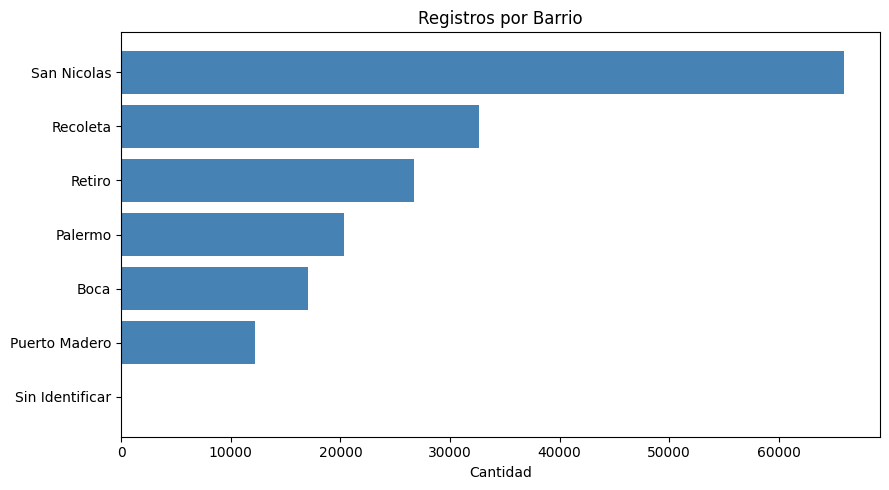

In [36]:
import matplotlib.pyplot as plt

conteo = df2["barrio"].value_counts()

plt.figure(figsize=(9, 5))
plt.barh(conteo.index, conteo.values, color="steelblue")
plt.gca().invert_yaxis()
plt.title("Registros por Barrio")
plt.xlabel("Cantidad")
plt.tight_layout()
plt.show()

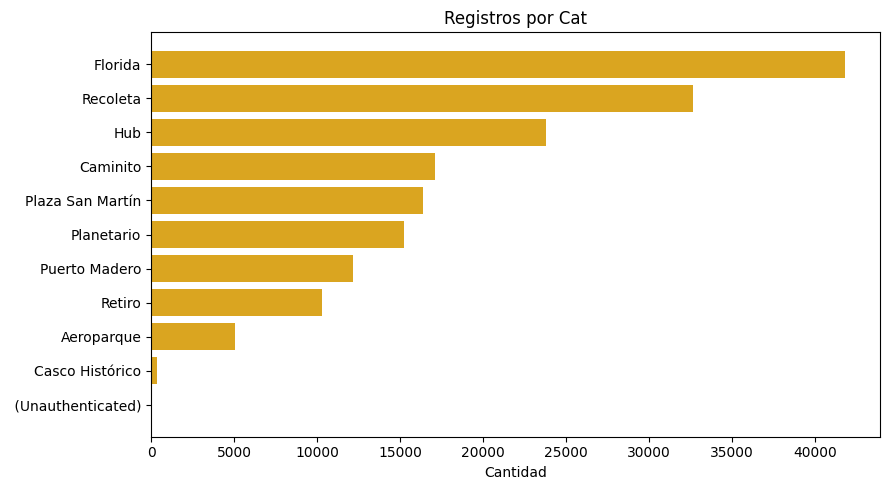

In [31]:
import matplotlib.pyplot as plt
conteo =df2["cat"].value_counts()

plt.figure(figsize=(9, 5))
plt.barh(conteo.index, conteo.values, color="goldenrod")
plt.gca().invert_yaxis()
plt.title("Registros por Cat")
plt.xlabel("Cantidad")
plt.tight_layout()
plt.show()

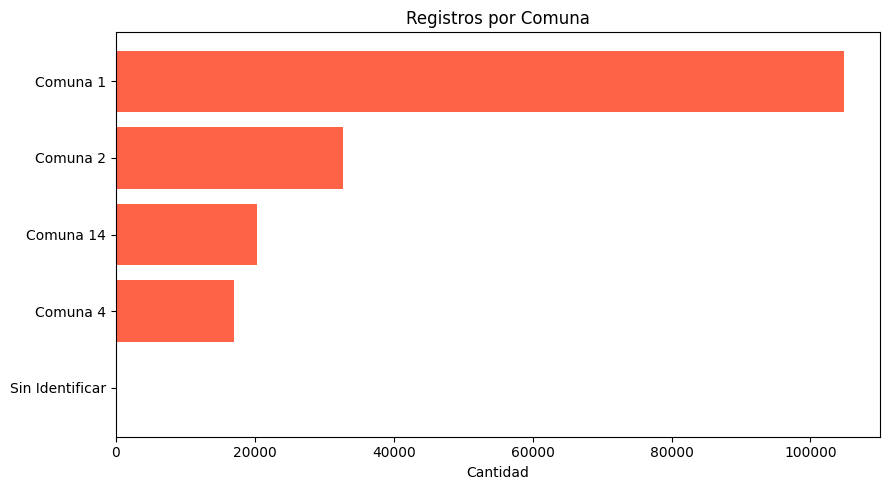

In [30]:
import matplotlib.pyplot as plt
conteo =df2["comuna"].value_counts()

plt.figure(figsize=(9, 5))
plt.barh(conteo.index, conteo.values, color="tomato")
plt.gca().invert_yaxis()
plt.title("Registros por Comuna")
plt.xlabel("Cantidad")
plt.tight_layout()
plt.show()

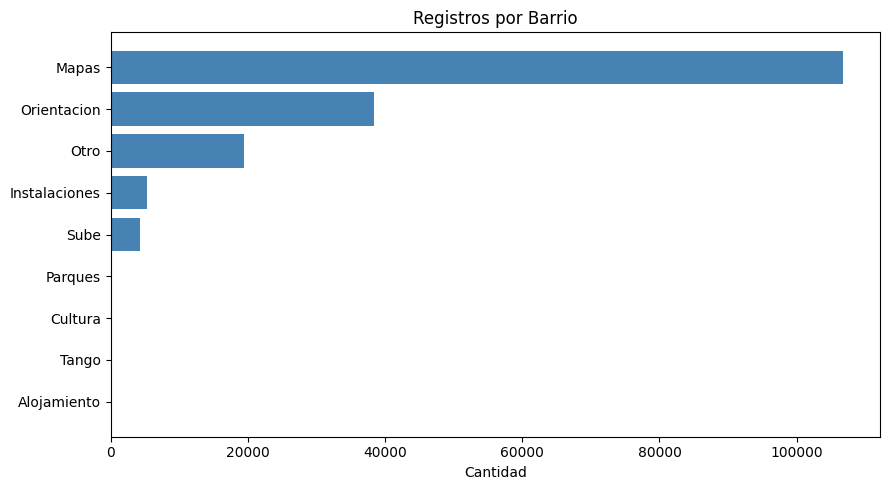

In [46]:
conteo = df2["motivo_consulta"].value_counts()

plt.figure(figsize=(9, 5))
plt.barh(conteo.index, conteo.values, color="steelblue")
plt.gca().invert_yaxis()
plt.title("Registros por Barrio")
plt.xlabel("Cantidad")
plt.tight_layout()
plt.show()

# Parte x - Guardar los datos en un nuevo archivo

In [17]:
#df2.to_excel("datosfinales.xlsx", index=False)
#files.download("datosfinales.xlsx")

print("El archivo se descargó correctamente")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

El archivo se descargó correctamente
